In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("urban_noise_levels.csv")

In [4]:
rush_hour = df[(df["hour"].between(7,9)) | (df["hour"].between(17,19))]
nighttime = df[(df["hour"] >= 22) | (df["hour"] < 6)]

features_rush = rush_hour[["latitude","longitude","decibel_level","traffic_density"]]
features_night = nighttime[["latitude","longitude","decibel_level","traffic_density"]]

In [5]:
scaler = StandardScaler()
X_rush = scaler.fit_transform(features_rush)
X_night = scaler.fit_transform(features_night)

In [6]:

kmeans_rush = KMeans(n_clusters=4, random_state=42).fit(X_rush)
rush_hour["Cluster"] = kmeans_rush.labels_

kmeans_night = KMeans(n_clusters=4, random_state=42).fit(X_night)
nighttime["Cluster"] = kmeans_night.labels_

C:\Users\RyanJ\AppData\Local\Temp\ipykernel_11808\2424135970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rush_hour["Cluster"] = kmeans_rush.labels_
C:\Users\RyanJ\AppData\Local\Temp\ipykernel_11808\2424135970.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nighttime["Cluster"] = kmeans_night.labels_


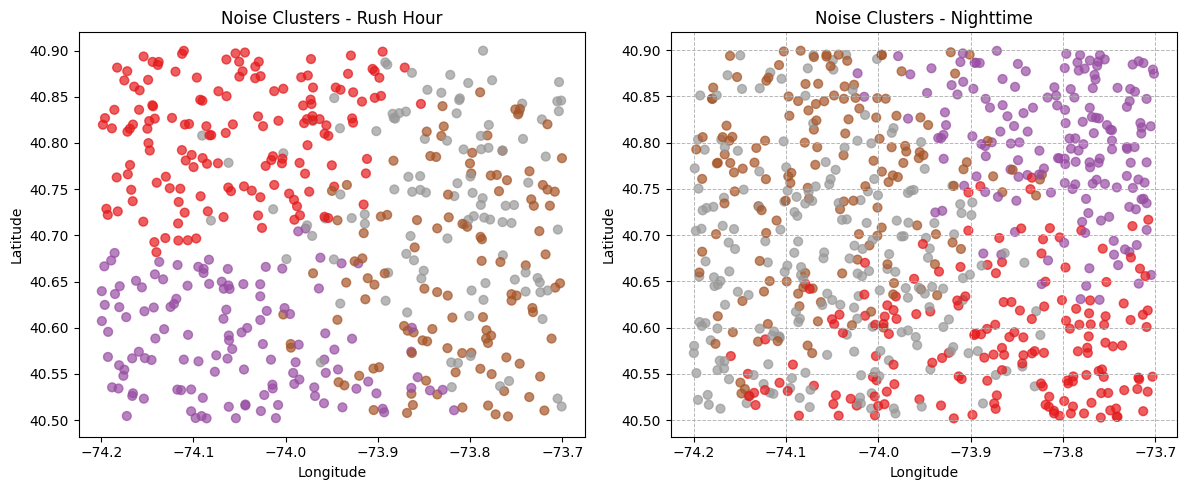

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Rush hour clusters
plt.subplot(1,2,1)
plt.scatter(rush_hour["longitude"], rush_hour["latitude"], 
            c=rush_hour["Cluster"], cmap="Set1", s=40, alpha=0.7)
plt.title("Noise Clusters - Rush Hour")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Nighttime clusters
plt.subplot(1,2,2)
plt.scatter(nighttime["longitude"], nighttime["latitude"], 
            c=nighttime["Cluster"], cmap="Set1", s=40, alpha=0.7)
plt.title("Noise Clusters - Nighttime")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.9)
plt.show()